# Credit Card Default Prediction
## Lightning Talk 2 — Deep EDA, Preprocessing & Modeling

### Refined Problem Statement

Financial institutions face significant losses due to credit card defaults. Traditional credit scoring fails to capture complex behavioral patterns in payment history. Using 30,000 Taiwan credit card clients with 24 features covering 6 months of payment status, bill amounts, and repayment history, we aim to build a binary classification model that predicts whether a client will default next month.

**Target:** `default payment next month` (0 = no default, 1 = default) — Binary Classification

loading imports

In [1]:
import sys
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xlrd'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# 1. UNDERSTANDING THE DATA

loading the dataset

In [2]:
df = pd.read_excel('default of credit card clients.xls', header=1)
df.shape

(30000, 25)

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [5]:
df.describe().round(2)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


**Data Dictionary:**

| Column | Type | Description |
|--------|------|-------------|
| ID | int | Client ID (dropped before modeling) |
| LIMIT_BAL | int | Credit limit in NT dollars |
| SEX | int | 1=male, 2=female |
| EDUCATION | int | 1=graduate, 2=university, 3=high school, 4=others |
| MARRIAGE | int | 1=married, 2=single, 3=others |
| AGE | int | Age in years |
| PAY_0 to PAY_6 | int | Repayment status (-1=paid duly, 1=1 month delay, ..., 9=9+ months delay) |
| BILL_AMT1-6 | int | Monthly bill statement (NT dollars) |
| PAY_AMT1-6 | int | Monthly payment amount (NT dollars) |
| default payment next month | int | **TARGET** (0=no default, 1=default) |

# 2. CLEANING THE DATA

check missing values and duplicates

In [6]:
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Shape before cleaning: {df.shape}')

Missing values: 0
Duplicate rows: 0
Shape before cleaning: (30000, 25)


drop ID, fix undocumented categories in EDUCATION and MARRIAGE

In [7]:
df = df.drop(columns=['ID'])
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
print('EDUCATION values after cleaning:')
print(df['EDUCATION'].value_counts().sort_index())
print()
print('MARRIAGE values after cleaning:')
print(df['MARRIAGE'].value_counts().sort_index())
print(f'\nShape after cleaning: {df.shape}')

EDUCATION values after cleaning:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE values after cleaning:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

Shape after cleaning: (30000, 24)


define column groups

In [8]:
target = 'default payment next month'
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
num_cols = ['LIMIT_BAL', 'AGE'] + bill_cols + pay_amt_cols
print('Column groups defined')

Column groups defined


# 3. DISTRIBUTION ANALYSIS

target distribution and class imbalance

Target distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Percentage:
default payment next month
0    77.9
1    22.1
Name: proportion, dtype: float64


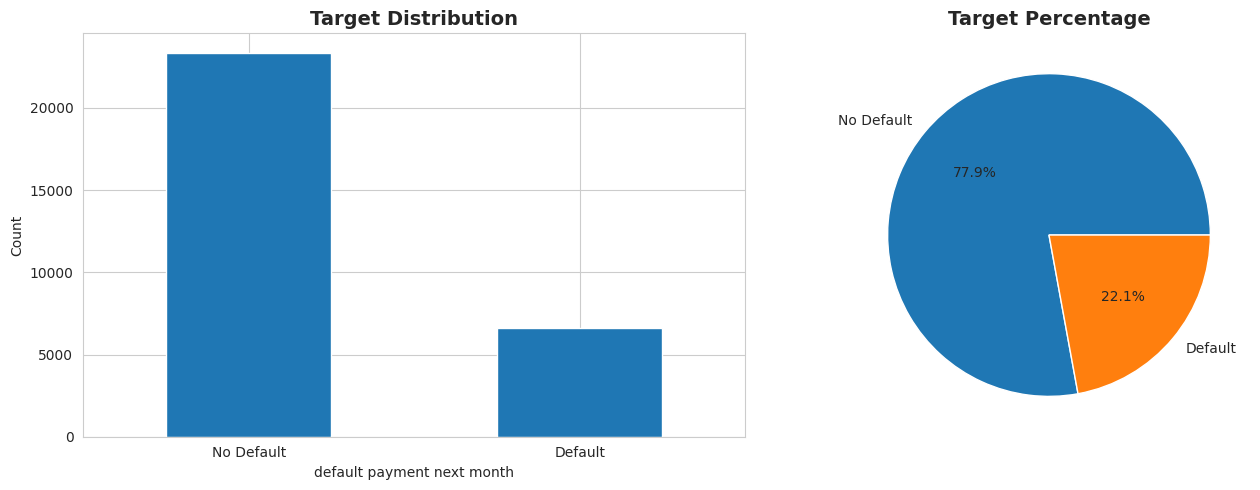

class imbalance detected: will fix with class_weight=balanced and stratified split


In [9]:
print('Target distribution:')
print(df[target].value_counts())
print()
print('Percentage:')
print(df[target].value_counts(normalize=True).round(3) * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[target].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[0].set_ylabel('Count')

df[target].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', labels=['No Default', 'Default'])
axes[1].set_title('Target Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print('class imbalance detected: will fix with class_weight=balanced and stratified split')

univariate distribution — numerical features

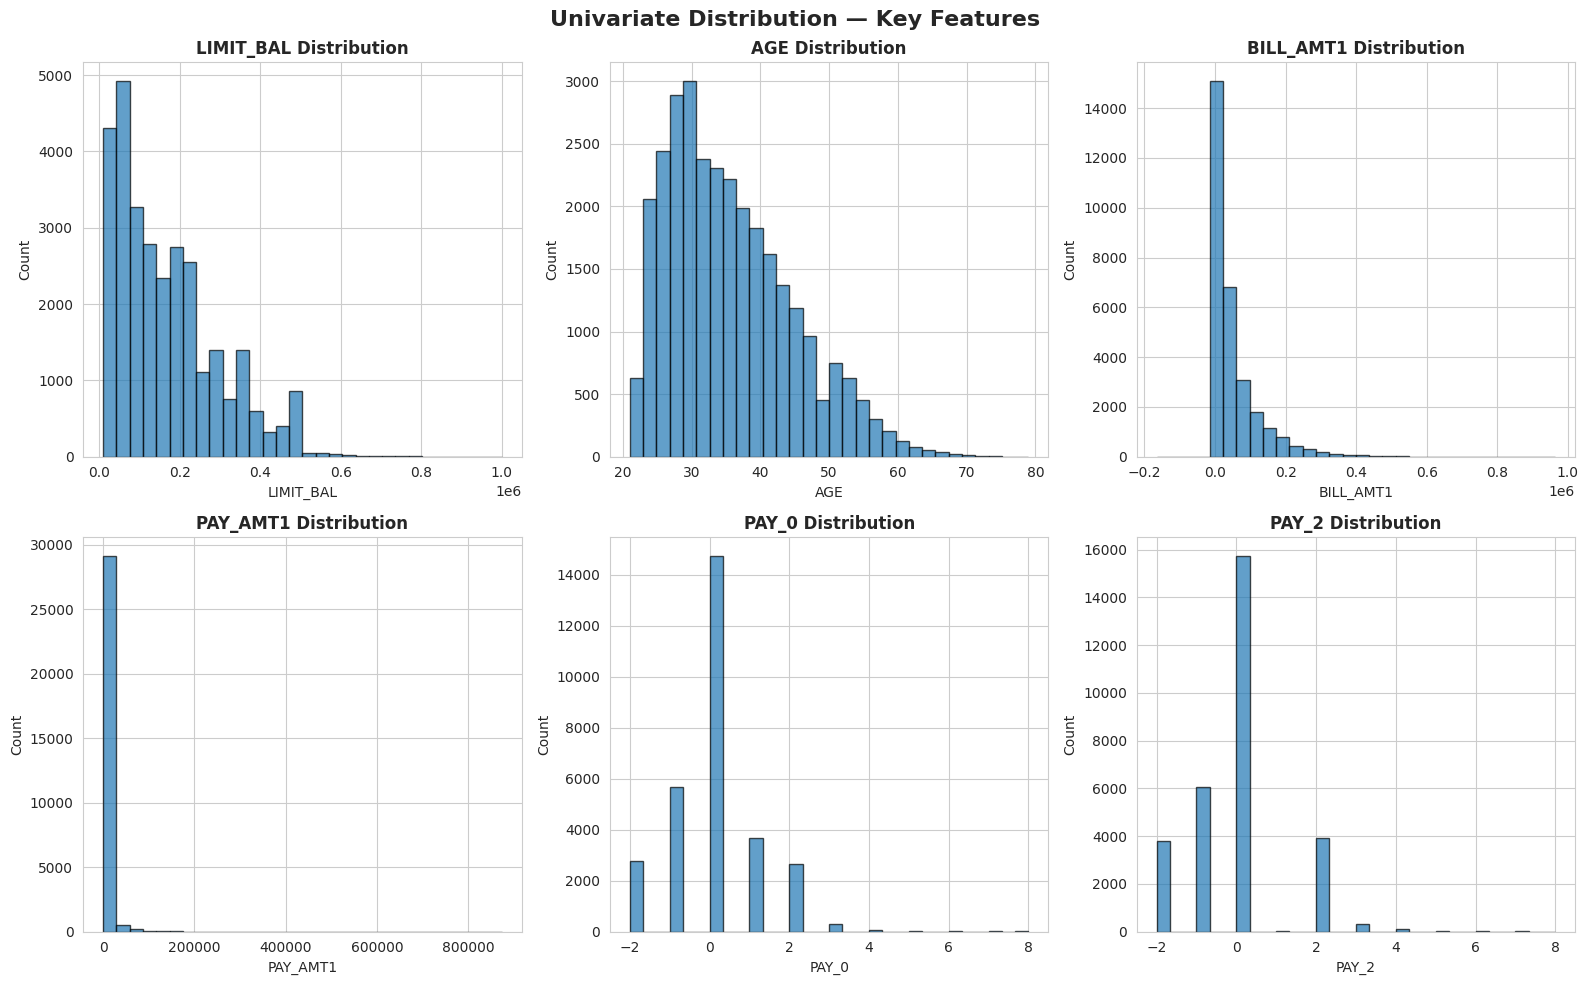

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0', 'PAY_2']
for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Univariate Distribution — Key Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

univariate distribution — categorical features

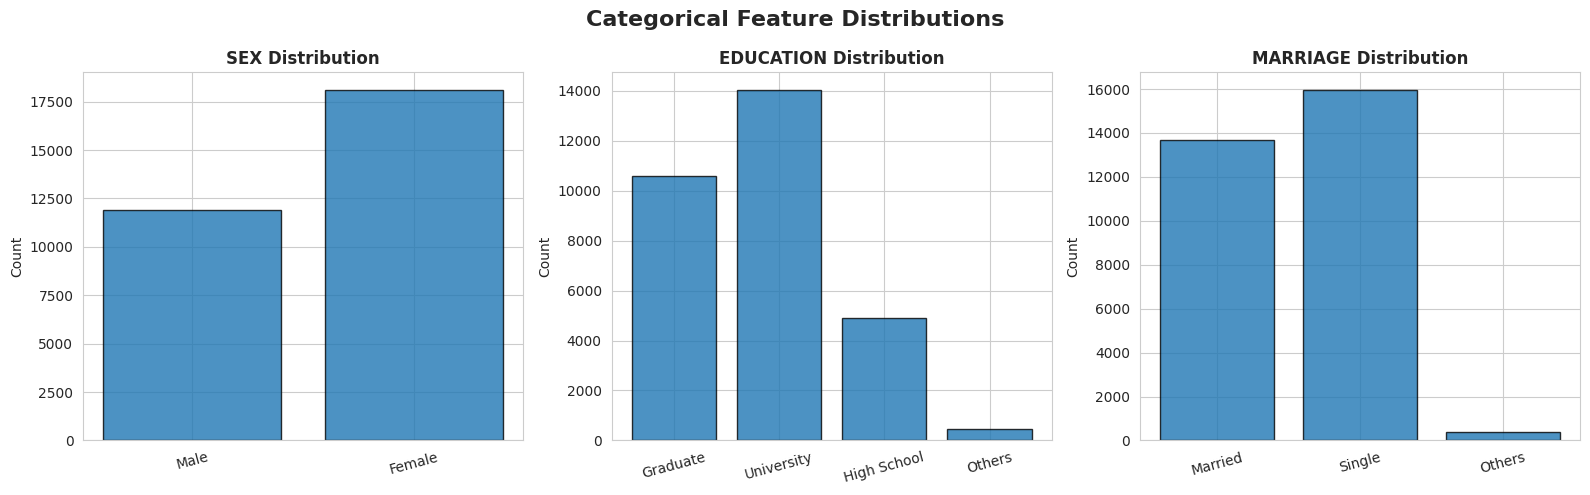

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = {
    'SEX': {1: 'Male', 2: 'Female'},
    'EDUCATION': {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'},
    'MARRIAGE': {1: 'Married', 2: 'Single', 3: 'Others'}
}

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().sort_index()
    tick_labels = [labels[col].get(k, str(k)) for k in counts.index]
    axes[i].bar(tick_labels, counts.values, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. CORRELATION + TRENDS

Pearson correlation — numerical features vs target

Pearson correlation with target:
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
AGE          0.014
BILL_AMT6   -0.005
BILL_AMT5   -0.007
BILL_AMT4   -0.010
BILL_AMT3   -0.014
BILL_AMT2   -0.014
BILL_AMT1   -0.020
PAY_AMT6    -0.053
PAY_AMT5    -0.055
PAY_AMT3    -0.056
PAY_AMT4    -0.057
PAY_AMT2    -0.059
PAY_AMT1    -0.073
LIMIT_BAL   -0.154


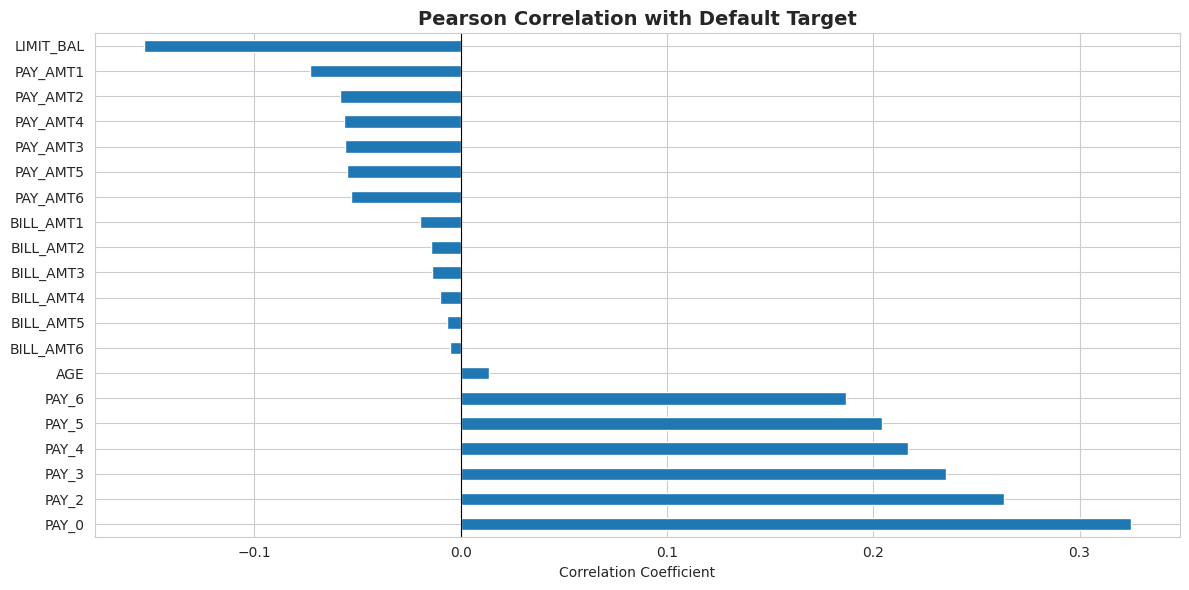

In [12]:
corr = df[num_cols + pay_cols].corrwith(df[target]).sort_values(ascending=False)
print('Pearson correlation with target:')
print(corr.round(3).to_string())

corr.plot(kind='barh')
plt.title('Pearson Correlation with Default Target', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

correlation heatmap

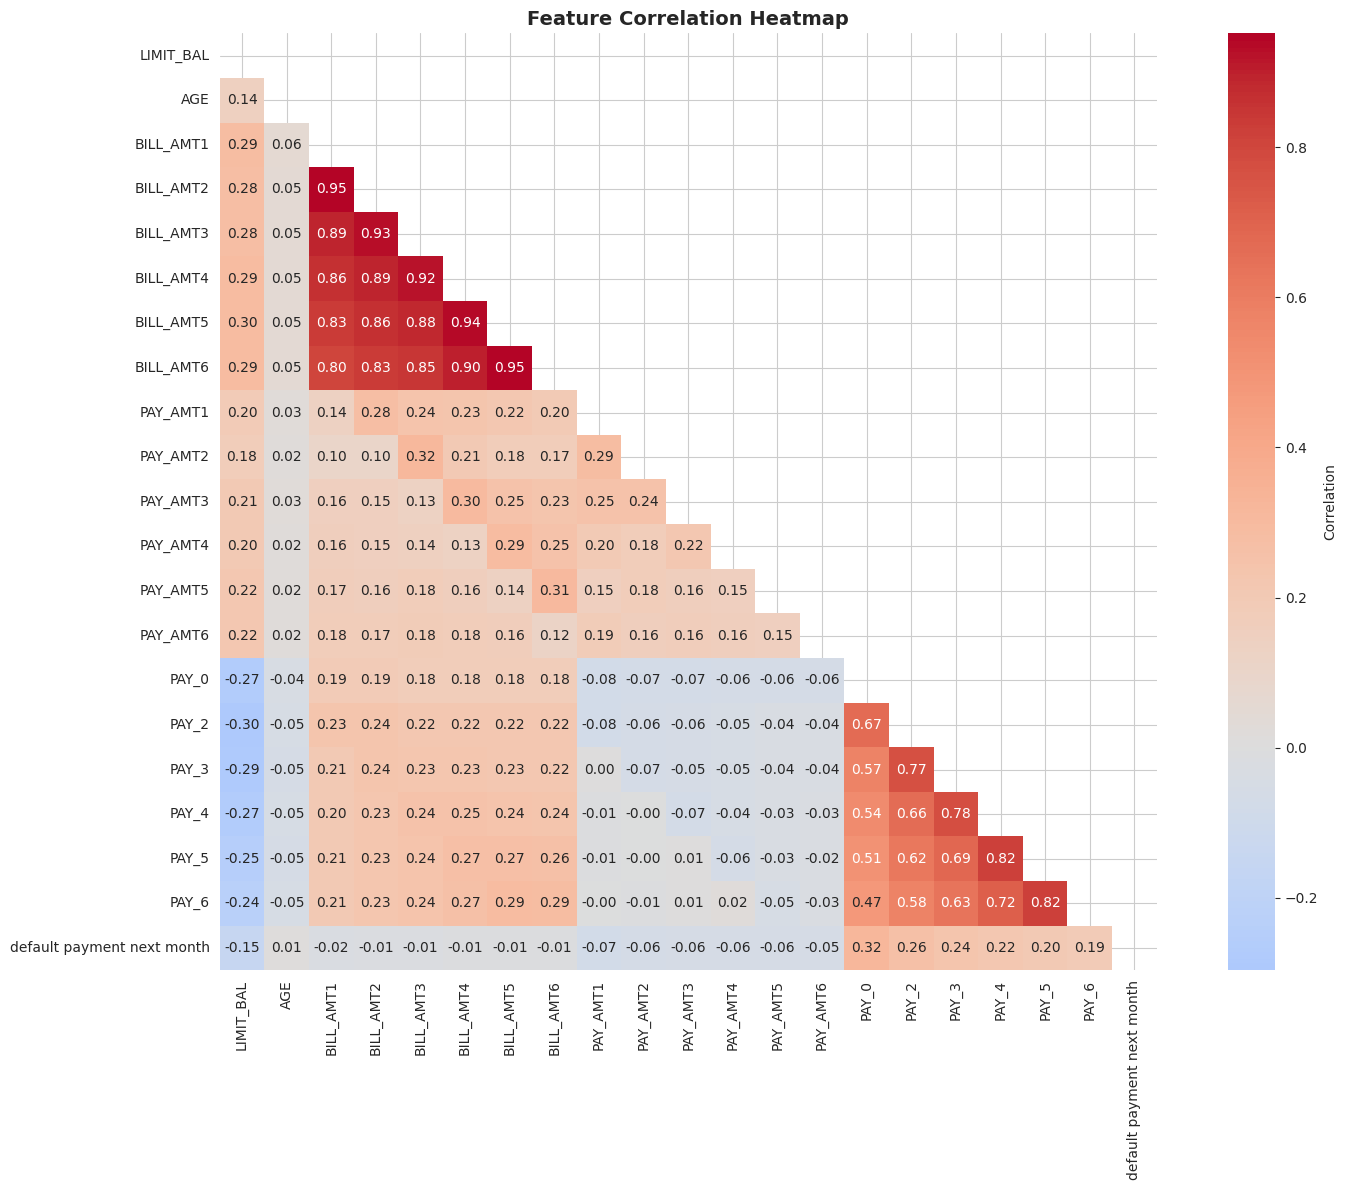

In [13]:
plt.figure(figsize=(16, 12))
corr_matrix = df[num_cols + pay_cols + [target]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Chi-Square test — categorical features vs target

In [14]:
print('Chi-Square Test Results:')
print('-' * 55)
for col in cat_cols:
    ct = pd.crosstab(df[col], df[target])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'{col:12s}: chi2={chi2:8.2f}, p={p:.4f} -> {sig}')

Chi-Square Test Results:
-------------------------------------------------------
SEX         : chi2=   47.71, p=0.0000 -> SIGNIFICANT
EDUCATION   : chi2=  160.41, p=0.0000 -> SIGNIFICANT
MARRIAGE    : chi2=   28.13, p=0.0000 -> SIGNIFICANT


bivariate analysis — key features vs default

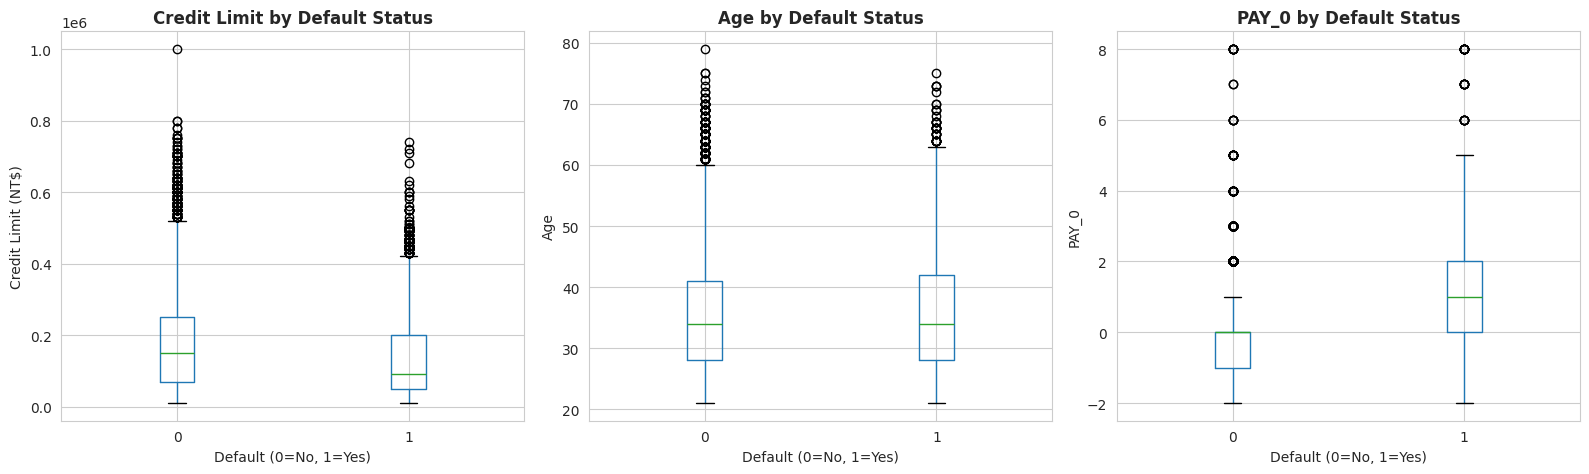

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df.boxplot(column='LIMIT_BAL', by=target, ax=axes[0])
axes[0].set_title('Credit Limit by Default Status', fontweight='bold')
axes[0].set_xlabel('Default (0=No, 1=Yes)')
axes[0].set_ylabel('Credit Limit (NT$)')

df.boxplot(column='AGE', by=target, ax=axes[1])
axes[1].set_title('Age by Default Status', fontweight='bold')
axes[1].set_xlabel('Default (0=No, 1=Yes)')
axes[1].set_ylabel('Age')

df.boxplot(column='PAY_0', by=target, ax=axes[2])
axes[2].set_title('PAY_0 by Default Status', fontweight='bold')
axes[2].set_xlabel('Default (0=No, 1=Yes)')
axes[2].set_ylabel('PAY_0')

plt.suptitle('')
plt.tight_layout()
plt.show()

multivariate — default rate by categorical features

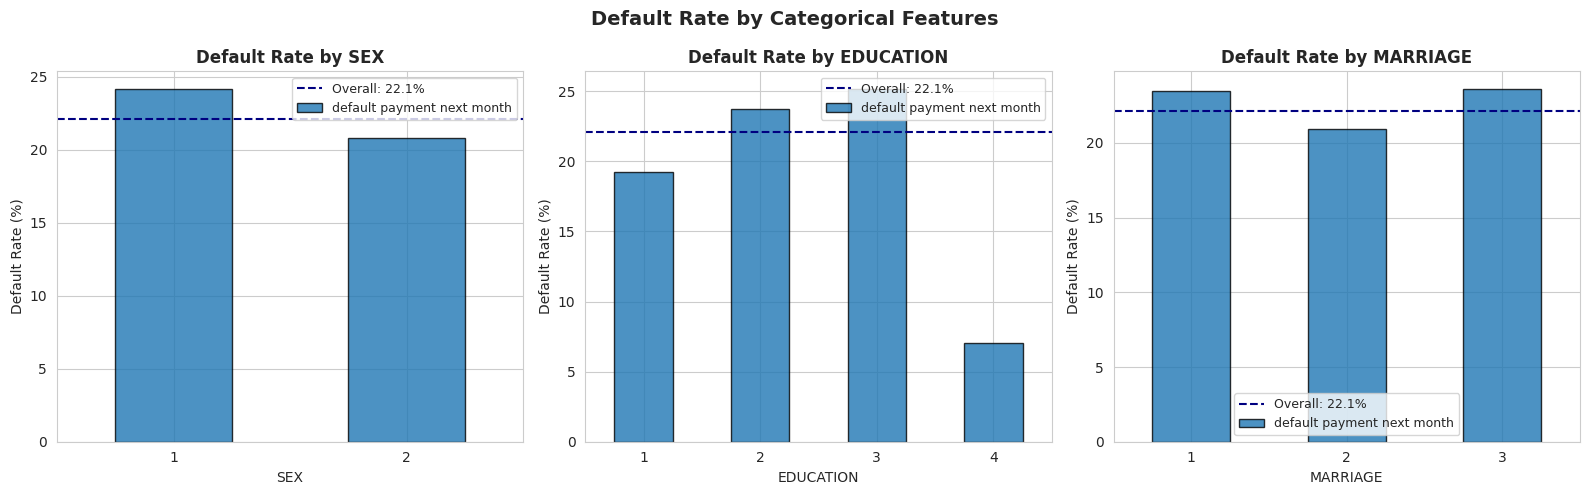

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    default_rate = df.groupby(col)[target].mean() * 100
    default_rate.plot(kind='bar', ax=axes[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].axhline(y=df[target].mean()*100, color='navy', linestyle='--',
                    linewidth=1.5, label=f'Overall: {df[target].mean()*100:.1f}%')
    axes[i].legend(fontsize=9)

plt.suptitle('Default Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. OUTLIER ANALYSIS

In [17]:
outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    if n > 0:
        outlier_summary.append({'Column': col, 'Count': int(n), 'Pct': f'{n/len(df)*100:.1f}%',
                                'Plan': 'Winsorize at 1st-99th percentile'})

print(pd.DataFrame(outlier_summary).to_string())

       Column  Count    Pct                              Plan
0   LIMIT_BAL    167   0.6%  Winsorize at 1st-99th percentile
1         AGE    272   0.9%  Winsorize at 1st-99th percentile
2   BILL_AMT1   2400   8.0%  Winsorize at 1st-99th percentile
3   BILL_AMT2   2395   8.0%  Winsorize at 1st-99th percentile
4   BILL_AMT3   2469   8.2%  Winsorize at 1st-99th percentile
5   BILL_AMT4   2622   8.7%  Winsorize at 1st-99th percentile
6   BILL_AMT5   2725   9.1%  Winsorize at 1st-99th percentile
7   BILL_AMT6   2693   9.0%  Winsorize at 1st-99th percentile
8    PAY_AMT1   2745   9.2%  Winsorize at 1st-99th percentile
9    PAY_AMT2   2714   9.0%  Winsorize at 1st-99th percentile
10   PAY_AMT3   2598   8.7%  Winsorize at 1st-99th percentile
11   PAY_AMT4   2994  10.0%  Winsorize at 1st-99th percentile
12   PAY_AMT5   2945   9.8%  Winsorize at 1st-99th percentile
13   PAY_AMT6   2958   9.9%  Winsorize at 1st-99th percentile


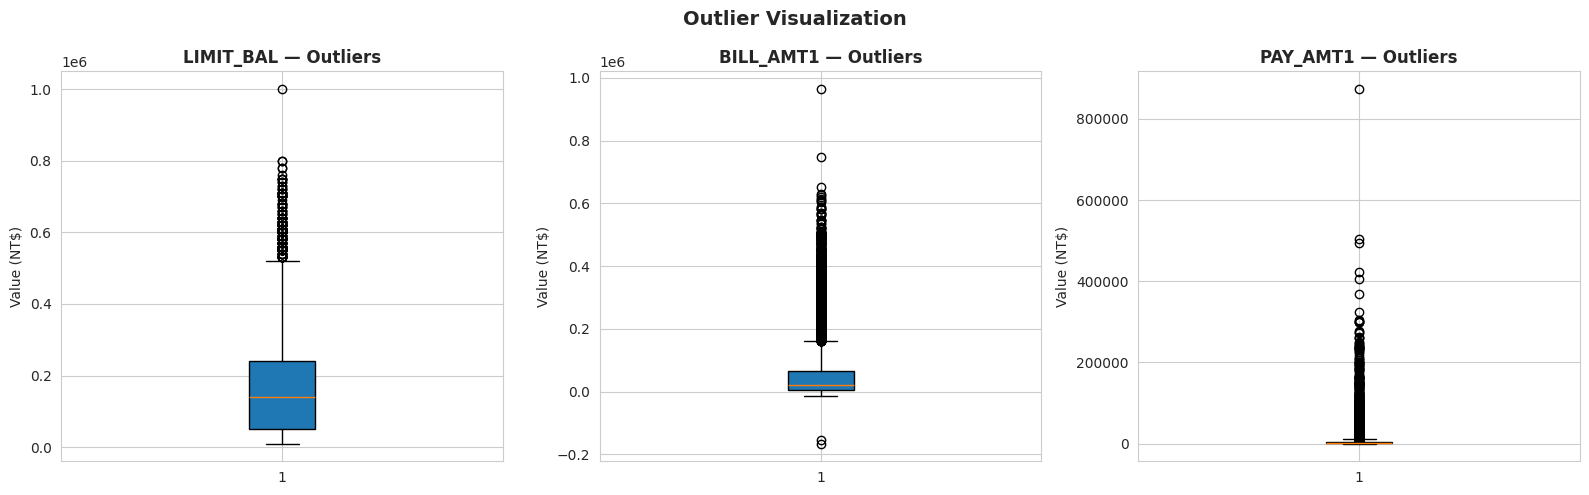

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']):
    bp = axes[i].boxplot(df[col], vert=True, patch_artist=True)
    axes[i].set_title(f'{col} — Outliers', fontweight='bold')
    axes[i].set_ylabel('Value (NT$)')

plt.suptitle('Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. PREPROCESSING

### Preprocessing Steps

**Step 1:** Drop ID column — not a predictive feature

**Step 2:** Recode EDUCATION (0, 5, 6 → 4) and MARRIAGE (0 → 3)

**Step 3:** Winsorize bill and payment columns at 1st and 99th percentile

**Step 4:** Create 5 engineered features

**Step 5:** StandardScaler — normalize all numerical features

**Step 6:** Stratified 80/20 train-test split

**Step 7:** class_weight=balanced in all classifiers

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_clean = df.copy()

df_clean['avg_pay_delay'] = df_clean[pay_cols].mean(axis=1)
df_clean['avg_bill_amt'] = df_clean[bill_cols].mean(axis=1)
df_clean['avg_pay_amt'] = df_clean[pay_amt_cols].mean(axis=1)
df_clean['pay_to_bill_ratio'] = df_clean['avg_pay_amt'] / (df_clean['avg_bill_amt'] + 1)
df_clean['total_delay_months'] = (df_clean[pay_cols] > 0).sum(axis=1)

df_clean = df_clean.fillna(0)

print('Feature engineering done')
print(f'New features: avg_pay_delay, avg_bill_amt, avg_pay_amt, pay_to_bill_ratio, total_delay_months')
print(f'Shape after engineering: {df_clean.shape}')
print()

for col in bill_cols + pay_amt_cols:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print('Winsorize done — outliers capped at 1st and 99th percentile')
print()

X = df_clean.drop(columns=[target])
X = X.select_dtypes(include=[np.number])
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train set: {X_train.shape} | Test set: {X_test.shape}')
print(f'Train target: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test target:  {y_test.value_counts(normalize=True).round(3).to_dict()}')
print('Stratified split preserved class ratio')

Feature engineering done
New features: avg_pay_delay, avg_bill_amt, avg_pay_amt, pay_to_bill_ratio, total_delay_months
Shape after engineering: (30000, 29)

Winsorize done — outliers capped at 1st and 99th percentile

Train set: (24000, 28) | Test set: (6000, 28)
Train target: {0: 0.779, 1: 0.221}
Test target:  {0: 0.779, 1: 0.221}
Stratified split preserved class ratio


# 7. MODELING PLAN

### Models

| Model | Purpose |
|-------|----------|
| Logistic Regression | Baseline — interpretable |
| Decision Tree | Easy to visualize |
| Random Forest | Primary model — ensemble, handles imbalance |
| XGBoost | Comparison — strong on tabular imbalanced data |

### Evaluation Metrics

| Metric | Why |
|--------|-----|
| **Recall** | Most important — catch real defaulters |
| **F1-Score** | Balance precision and recall |
| **ROC-AUC** | Overall model separation |
| **Confusion Matrix** | Full TP, FP, TN, FN breakdown |

> Accuracy is not the primary metric — a model predicting class 0 always scores 77.9% but catches zero defaulters.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Recall': round(recall_score(y_test, y_pred), 3),
        'F1': round(f1_score(y_test, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Recall    F1  ROC-AUC
Logistic Regression     0.762   0.569 0.514    0.746
      Decision Tree     0.747   0.638 0.527    0.765
      Random Forest     0.810   0.332 0.436    0.754


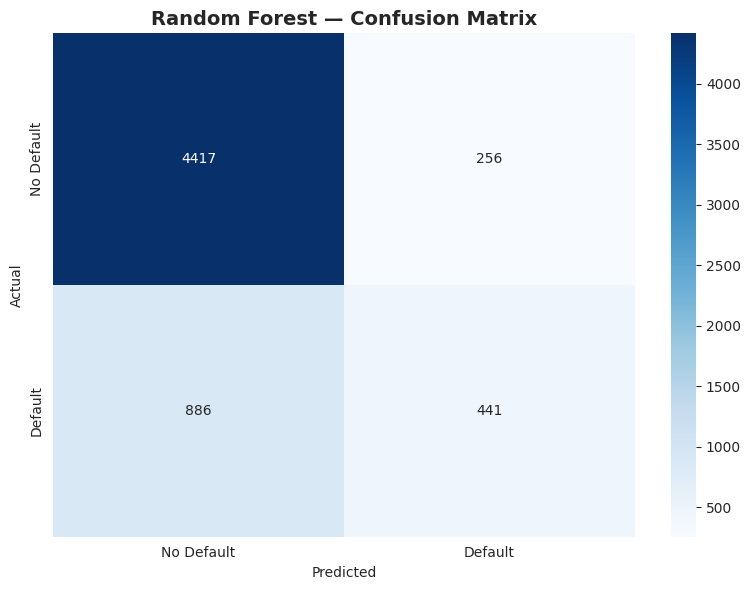

              precision    recall  f1-score   support

  No Default       0.83      0.95      0.89      4673
     Default       0.63      0.33      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000



In [21]:
from sklearn.metrics import confusion_matrix, classification_report

best_model = models['Random Forest']
y_pred_rf = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=['No Default', 'Default']))

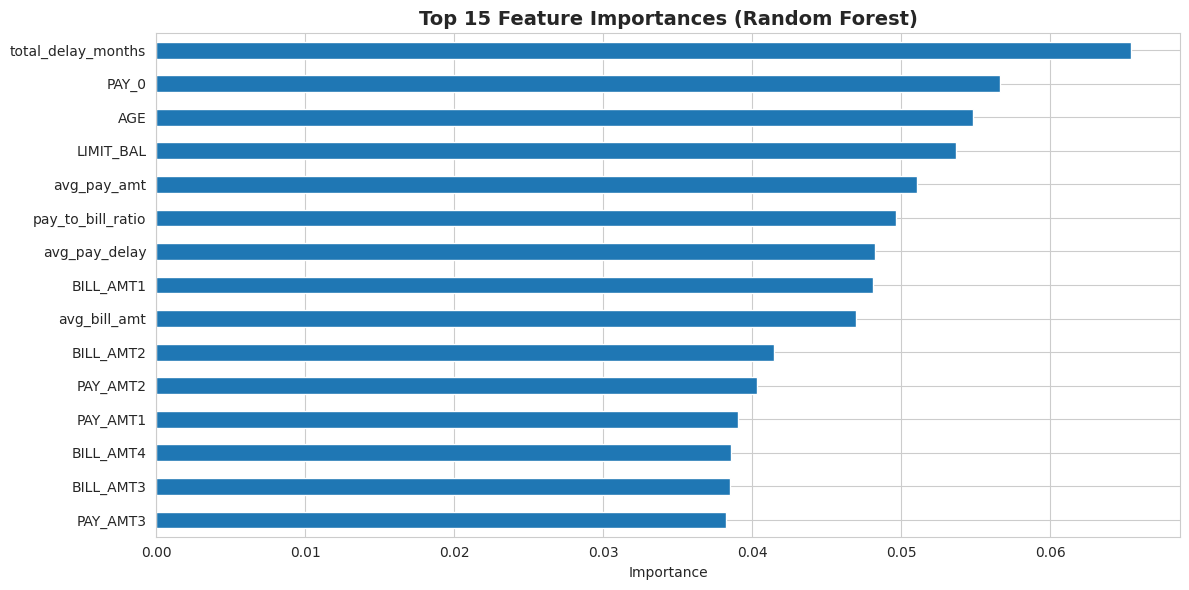

Top 5 most important features:
total_delay_months    0.0654
PAY_0                 0.0566
AGE                   0.0548
LIMIT_BAL             0.0537
avg_pay_amt           0.0510


In [22]:
feature_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

feature_imp.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feature_imp.head(5).round(4).to_string())

## Summary

In [23]:
print('LIGHTNING TALK 2 SUMMARY — CREDIT CARD DEFAULT')
print('='*60)
print(f'Dataset: 30,000 clients | 24 features | 0 missing')
print(f'Target: default payment next month (Binary Classification)')
print(f'Imbalance: 77.9% No Default vs 22.1% Default')
print(f'Fix: class_weight=balanced + stratified split')
print()
print('Key EDA Findings:')
print('  PAY_0 strongest predictor (r=0.325)')
print('  LIMIT_BAL strongest financial differentiator')
print('  SEX, EDUCATION, MARRIAGE all significant (Chi-Square p<0.05)')
print('  Outliers in bill/payment columns — Winsorized')
print()
print('Feature Engineering: 5 new features (28 total)')
print('Best Model: Random Forest (class_weight=balanced)')
print('Primary Metric: Recall')

LIGHTNING TALK 2 SUMMARY — CREDIT CARD DEFAULT
Dataset: 30,000 clients | 24 features | 0 missing
Target: default payment next month (Binary Classification)
Imbalance: 77.9% No Default vs 22.1% Default
Fix: class_weight=balanced + stratified split

Key EDA Findings:
  PAY_0 strongest predictor (r=0.325)
  LIMIT_BAL strongest financial differentiator
  SEX, EDUCATION, MARRIAGE all significant (Chi-Square p<0.05)
  Outliers in bill/payment columns — Winsorized

Feature Engineering: 5 new features (28 total)
Best Model: Random Forest (class_weight=balanced)
Primary Metric: Recall
